# Installation

In [1]:
%%capture
import sys
import warnings
warnings.filterwarnings("ignore")
!pip install --upgrade PyYAML>=6.0.2
!pip install --upgrade urllib3>=2.0.0
!pip install --upgrade websockets==15.0.1
!pip install --upgrade toolz==0.11.0
!pip install torch_geometric
!pip install stable_baselines3
!pip install alpaca_trade_api
!pip install exchange_calendars
!pip install stockstats
!pip install --upgrade websockets yfinance
!pip install wrds
!pip install quantstats
## install finrl library
!sudo apt install swig
!pip install shimmy
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git


In [2]:
import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split, GroupByScaler
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
import torch
from sklearn.preprocessing import MaxAbsScaler
import pandas as pd
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import GroupByScaler
# from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
# from finrl.agents.portfolio_optimization.models import DRLAgent
from finrl.agents.portfolio_optimization.architectures import EIIE
import numpy as np
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
import torch as th
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.vec_env import DummyVecEnv # Added import
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# FinRL Portfolio Optimization Environment

We made some small modifications to the PortfolioOptimizationEnv in FinRL, so we copy it here for more granular control rather than importing it from FinRL directly.

Source: https://github.com/AI4Finance-LLC/FinRL/tree/master/finrl/env

In [3]:
"""From FinRL https://github.com/AI4Finance-LLC/FinRL/tree/master/finrl/env"""

from __future__ import annotations

import math
import gymnasium as gym
import matplotlib
import numpy as np
import pandas as pd
from gymnasium import spaces
from gymnasium.utils import seeding

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from stable_baselines3.common.vec_env import DummyVecEnv
from pathlib import Path

try:
    import quantstats as qs
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        """QuantStats module not found, environment can't plot results and calculate indicadors.
        This module is not installed with FinRL. Install by running one of the options:
        pip install quantstats --upgrade --no-cache-dir
        conda install -c ranaroussi quantstats
        """
    )


class PortfolioOptimizationEnv(gym.Env):
    """A portfolio allocation environment for OpenAI gym.

    This environment simulates the interactions between an agent and the financial market
    based on data provided by a dataframe. The dataframe contains the time series of
    features defined by the user (such as closing, high and low prices) and must have
    a time and a tic column with a list of datetimes and ticker symbols respectively.
    An example of dataframe is shown below::

            date        high            low             close           tic
        0   2020-12-23  0.157414        0.127420        0.136394        ADA-USD
        1   2020-12-23  34.381519       30.074295       31.097898       BNB-USD
        2   2020-12-23  24024.490234    22802.646484    23241.345703    BTC-USD
        3   2020-12-23  0.004735        0.003640        0.003768        DOGE-USD
        4   2020-12-23  637.122803      560.364258      583.714600      ETH-USD
        ... ...         ...             ...             ...             ...

    Based on this dataframe, the environment will create an observation space that can
    be a Dict or a Box. The Box observation space is a three-dimensional array of shape
    (f, n, t), where f is the number of features, n is the number of stocks in the
    portfolio and t is the user-defined time window. If the environment is created with
    the parameter return_last_action set to True, the observation space is a Dict with
    the following keys::

        {
        "state": three-dimensional Box (f, n, t) representing the time series,
        "last_action": one-dimensional Box (n+1,) representing the portfolio weights
        }

    Note that the action space of this environment is an one-dimensional Box with size
    n + 1 because the portfolio weights must contains the weights related to all the
    stocks in the portfolio and to the remaining cash.

    Attributes:
        action_space: Action space.
        observation_space: Observation space.
        episode_length: Number of timesteps of an episode.
        portfolio_size: Number of stocks in the portfolio.
    """

    metadata = {"render.modes": ["human"]}

    def __init__(
        self,
        df,
        initial_amount,
        order_df=True,
        return_last_action=False,
        normalize_df="by_previous_time",
        reward_scaling=1,
        comission_fee_model="trf",
        comission_fee_pct=0,
        features=["close", "high", "low"],
        valuation_feature="close",
        time_column="date",
        time_format="%Y-%m-%d",
        tic_column="tic",
        tics_in_portfolio="all",
        time_window=1,
        cwd="./",
        new_gym_api=False,
    ):
        """Initializes environment's instance.

        Args:
            df: Dataframe with market information over a period of time.
            initial_amount: Initial amount of cash available to be invested.
            order_df: If True input dataframe is ordered by time.
            return_last_action: If True, observations also return the last performed
                action. Note that, in that case, the observation space is a Dict.
            normalize_df: Defines the normalization method applied to input dataframe.
                Possible values are "by_previous_time", "by_fist_time_window_value",
                "by_COLUMN_NAME" (where COLUMN_NAME must be changed to a real column
                name) and a custom function. If None no normalization is done.
            reward_scaling: A scaling factor to multiply the reward function. This
                factor can help training.
            comission_fee_model: Model used to simulate comission fee. Possible values
                are "trf" (for transaction remainder factor model) and "wvm" (for weights
                vector modifier model). If None, commission fees are not considered.
            comission_fee_pct: Percentage to be used in comission fee. It must be a value
                between 0 and 1.
            features: List of features to be considered in the observation space. The
                items of the list must be names of columns of the input dataframe.
            valuation_feature: Feature to be considered in the portfolio value calculation.
            time_column: Name of the dataframe's column that contain the datetimes that
                index the dataframe.
            time_format: Formatting string of time column.
            tic_name: Name of the dataframe's column that contain ticker symbols.
            tics_in_portfolio: List of ticker symbols to be considered as part of the
                portfolio. If "all", all tickers of input data are considered.
            time_window: Size of time window.
            cwd: Local repository in which resulting graphs will be saved.
            new_gym_api: If True, the environment will use the new gym api standard for
                step and reset methods.
        """
        self._time_window = time_window
        self._time_index = time_window - 1
        self._time_column = time_column
        self._time_format = time_format
        self._tic_column = tic_column
        self._df = df
        self._initial_amount = initial_amount
        self._return_last_action = return_last_action
        self._reward_scaling = reward_scaling
        self._comission_fee_pct = comission_fee_pct
        self._comission_fee_model = comission_fee_model
        self._features = features
        self._valuation_feature = valuation_feature
        self._cwd = Path(cwd)
        self._new_gym_api = new_gym_api

        # results file
        self._results_file = self._cwd / "results" / "rl"
        self._results_file.mkdir(parents=True, exist_ok=True)

        # initialize price variation
        self._df_price_variation = None

        # preprocess data
        self._preprocess_data(order_df, normalize_df, tics_in_portfolio)

        # dims and spaces
        self._tic_list = self._df[self._tic_column].unique()
        self.portfolio_size = (
            len(self._tic_list)
            if tics_in_portfolio == "all"
            else len(tics_in_portfolio)
        )
        action_space = 1 + self.portfolio_size

        # sort datetimes and define episode length
        self._sorted_times = sorted(set(self._df[time_column]))
        self.episode_length = len(self._sorted_times) - time_window + 1

        # define action space
        self.action_space = spaces.Box(low=0, high=1, shape=(action_space,))

        # define observation state
        if self._return_last_action:
            # if  last action must be returned, a dict observation
            # is defined
            self.observation_space = spaces.Dict(
                {
                    "state": spaces.Box(
                        low=-np.inf,
                        high=np.inf,
                        shape=(
                            len(self._features),
                            len(self._tic_list),
                            self._time_window,
                        ),
                    ),
                    "last_action": spaces.Box(low=0, high=1, shape=(action_space,)),
                }
            )
        else:
            # if information about last action is not relevant,
            # a 3D observation space is defined
            self.observation_space = spaces.Box(
                low=-np.inf,
                high=np.inf,
                shape=(len(self._features), len(self._tic_list), self._time_window),
            )

        self._reset_memory()

        self._portfolio_value = self._initial_amount
        self._terminal = False

    def step(self, actions):
        """Performs a simulation step.

        Args:
            actions: An unidimensional array containing the new portfolio
                weights.

        Note:
            If the environment was created with "return_last_action" set to
            True, the next state returned will be a Dict. If it's set to False,
            the next state will be a Box. You can check the observation state
            through the attribute "observation_space".

        Returns:
            If "new_gym_api" is set to True, the following tuple is returned:
            (state, reward, terminal, truncated, info). If it's set to False,
            the following tuple is returned: (state, reward, terminal, info).

            state: Next simulation state.
            reward: Reward related to the last performed action.
            terminal: If True, the environment is in a terminal state.
            truncated: If True, the environment has passed it's simulation
                time limit. Currently, it's always False.
            info: A dictionary containing informations about the last state.
        """
        self._terminal = self._time_index >= len(self._sorted_times) - 1

        if self._terminal:
            metrics_df = pd.DataFrame(
                {
                    "date": self._date_memory,
                    "returns": self._portfolio_return_memory,
                    "rewards": self._portfolio_reward_memory,
                    "portfolio_values": self._asset_memory["final"],
                }
            )
            metrics_df.set_index("date", inplace=True)

            plt.plot(metrics_df["portfolio_values"], "r")
            plt.title("Portfolio Value Over Time")
            plt.xlabel("Time")
            plt.ylabel("Portfolio value")
            plt.savefig(self._results_file / "portfolio_value.png")
            plt.close()

            plt.plot(self._portfolio_reward_memory, "r")
            plt.title("Reward Over Time")
            plt.xlabel("Time")
            plt.ylabel("Reward")
            plt.savefig(self._results_file / "reward.png")
            plt.close()

            plt.plot(self._actions_memory)
            plt.title("Actions performed")
            plt.xlabel("Time")
            plt.ylabel("Weight")
            plt.savefig(self._results_file / "actions.png")
            plt.close()

            print("=================================")
            print("Initial portfolio value:{}".format(self._asset_memory["final"][0]))
            print(f"Final portfolio value: {self._portfolio_value}")
            print(
                "Final accumulative portfolio value: {}".format(
                    self._portfolio_value / self._asset_memory["final"][0]
                )
            )
            print(
                "Maximum DrawDown: {}".format(
                    qs.stats.max_drawdown(metrics_df["portfolio_values"])
                )
            )
            print("Sharpe ratio: {}".format(qs.stats.sharpe(metrics_df["returns"])))
            print("=================================")

            qs.plots.snapshot(
                metrics_df["returns"],
                show=False,
                savefig=self._results_file / "portfolio_summary.png",
            )

            if self._new_gym_api:
                return self._state, self._reward, self._terminal, False, self._info
            return self._state, self._reward, self._terminal, self._info

        else:
            # transform action to numpy array (if it's a list)
            actions = np.array(actions, dtype=np.float32)

            # if necessary, normalize weights
            if math.isclose(np.sum(actions), 1, abs_tol=1e-6) and np.min(actions) >= 0:
                weights = actions
            else:
                weights = self._softmax_normalization(actions)

            # save initial portfolio weights for this time step
            self._actions_memory.append(weights)

            # get last step final weights and portfolio_value
            last_weights = self._final_weights[-1]

            # load next state
            self._time_index += 1
            self._state, self._info = self._get_state_and_info_from_time_index(
                self._time_index
            )

            # if using weights vector modifier, we need to modify weights vector
            if self._comission_fee_model == "wvm":
                delta_weights = weights - last_weights
                delta_assets = delta_weights[1:]  # disconsider
                # calculate fees considering weights modification
                fees = np.sum(np.abs(delta_assets * self._portfolio_value))
                if fees > weights[0] * self._portfolio_value:
                    weights = last_weights
                    # maybe add negative reward
                else:
                    portfolio = weights * self._portfolio_value
                    portfolio[0] -= fees
                    self._portfolio_value = np.sum(portfolio)  # new portfolio value
                    weights = portfolio / self._portfolio_value  # new weights
            elif self._comission_fee_model == "trf":
                last_mu = 1
                mu = 1 - 2 * self._comission_fee_pct + self._comission_fee_pct**2
                while abs(mu - last_mu) > 1e-10:
                    last_mu = mu
                    mu = (
                        1
                        - self._comission_fee_pct * weights[0]
                        - (2 * self._comission_fee_pct - self._comission_fee_pct**2)
                        * np.sum(np.maximum(last_weights[1:] - mu * weights[1:], 0))
                    ) / (1 - self._comission_fee_pct * weights[0])
                self._info["trf_mu"] = mu
                self._portfolio_value = mu * self._portfolio_value

            # save initial portfolio value of this time step
            self._asset_memory["initial"].append(self._portfolio_value)

            # time passes and time variation changes the portfolio distribution
            portfolio = self._portfolio_value * (weights * self._price_variation)

            # calculate new portfolio value and weights
            self._portfolio_value = np.sum(portfolio)
            weights = portfolio / self._portfolio_value

            # save final portfolio value and weights of this time step
            self._asset_memory["final"].append(self._portfolio_value)
            self._final_weights.append(weights)

            # save date memory
            self._date_memory.append(self._info["end_time"])

            # define portfolio return
            rate_of_return = (
                self._asset_memory["final"][-1] / self._asset_memory["final"][-2]
            )
            portfolio_return = rate_of_return - 1
            portfolio_reward = np.log(rate_of_return)

            # save portfolio return memory
            self._portfolio_return_memory.append(portfolio_return)
            self._portfolio_reward_memory.append(portfolio_reward)

            # Define portfolio return
            self._reward = portfolio_reward
            self._reward = self._reward * self._reward_scaling

        if self._new_gym_api:
            return self._state, self._reward, self._terminal, False, self._info
        return self._state, self._reward, self._terminal, self._info

    def reset(self):
        """Resets the environment and returns it to its initial state (the
        fist date of the dataframe).

        Note:
            If the environment was created with "return_last_action" set to
            True, the initial state will be a Dict. If it's set to False,
            the initial state will be a Box. You can check the observation
            state through the attribute "observation_space".

        Returns:
            If "new_gym_api" is set to True, the following tuple is returned:
            (state, info). If it's set to False, only the initial state is
            returned.

            state: Initial state.
            info: Initial state info.
        """
        # time_index must start a little bit in the future to implement lookback
        self._time_index = self._time_window - 1
        self._reset_memory()

        self._state, self._info = self._get_state_and_info_from_time_index(
            self._time_index
        )
        self._portfolio_value = self._initial_amount
        self._terminal = False

        if self._new_gym_api:
            return self._state, self._info
        return self._state

    def _get_state_and_info_from_time_index(self, time_index):
        """Gets state and information given a time index. It also updates "data"
        attribute with information about the current simulation step.

        Args:
            time_index: An integer that represents the index of a specific datetime.
                The initial datetime of the dataframe is given by 0.

        Note:
            If the environment was created with "return_last_action" set to
            True, the returned state will be a Dict. If it's set to False,
            the returned state will be a Box. You can check the observation
            state through the attribute "observation_space".

        Returns:
            A tuple with the following form: (state, info).

            state: The state of the current time index. It can be a Box or a Dict.
            info: A dictionary with some informations about the current simulation
                step. The dict has the following keys::

                {
                "tics": List of ticker symbols,
                "start_time": Start time of current time window,
                "start_time_index": Index of start time of current time window,
                "end_time": End time of current time window,
                "end_time_index": Index of end time of current time window,
                "data": Data related to the current time window,
                "price_variation": Price variation of current time step
                }
        """
        # returns state in form (channels, tics, timesteps)
        end_time = self._sorted_times[time_index]
        start_time = self._sorted_times[time_index - (self._time_window - 1)]

        # define data to be used in this time step
        self._data = self._df[
            (self._df[self._time_column] >= start_time)
            & (self._df[self._time_column] <= end_time)
        ][[self._time_column, self._tic_column] + self._features]

        # define price variation of this time_step
        self._price_variation = self._df_price_variation[
            self._df_price_variation[self._time_column] == end_time
        ][self._valuation_feature].to_numpy()
        self._price_variation = np.insert(self._price_variation, 0, 1)

        # define state to be returned
        state = None
        for tic in self._tic_list:
            tic_data = self._data[self._data[self._tic_column] == tic]
            tic_data = tic_data[self._features].to_numpy().T
            tic_data = tic_data[..., np.newaxis]
            state = tic_data if state is None else np.append(state, tic_data, axis=2)
        state = state.transpose((0, 2, 1))
        info = {
            "tics": self._tic_list,
            "start_time": start_time,
            "start_time_index": time_index - (self._time_window - 1),
            "end_time": end_time,
            "end_time_index": time_index,
            "data": self._data,
            "price_variation": self._price_variation,
        }
        return self._standardize_state(state), info

    def render(self, mode="human"):
        """Renders the environment.

        Returns:
            Observation of current simulation step.
        """
        return self._state

    def _softmax_normalization(self, actions):
        """Normalizes the action vector using softmax function.

        Returns:
            Normalized action vector (portfolio vector).
        """
        numerator = np.exp(actions)
        denominator = np.sum(np.exp(actions))
        softmax_output = numerator / denominator
        return softmax_output

    def enumerate_portfolio(self):
        """Enumerates the current porfolio by showing the ticker symbols
        of all the investments considered in the portfolio.
        """
        print("Index: 0. Tic: Cash")
        for index, tic in enumerate(self._tic_list):
            print(f"Index: {index + 1}. Tic: {tic}")

    def _preprocess_data(self, order, normalize, tics_in_portfolio):
        """Orders and normalizes the environment's dataframe.

        Args:
            order: If true, the dataframe will be ordered by ticker list
                and datetime.
            normalize: Defines the normalization method applied to the dataframe.
                Possible values are "by_previous_time", "by_fist_time_window_value",
                "by_COLUMN_NAME" (where COLUMN_NAME must be changed to a real column
                name) and a custom function. If None no normalization is done.
            tics_in_portfolio: List of ticker symbols to be considered as part of the
                portfolio. If "all", all tickers of input data are considered.
        """
        # order time dataframe by tic and time
        if order:
            self._df = self._df.sort_values(by=[self._tic_column, self._time_column])
        # defining price variation after ordering dataframe
        self._df_price_variation = self._temporal_variation_df()
        # select only stocks in portfolio
        if tics_in_portfolio != "all":
            self._df_price_variation = self._df_price_variation[
                self._df_price_variation[self._tic_column].isin(tics_in_portfolio)
            ]
        # apply normalization
        if normalize:
            self._normalize_dataframe(normalize)
        # transform str to datetime
        self._df[self._time_column] = pd.to_datetime(self._df[self._time_column])
        self._df_price_variation[self._time_column] = pd.to_datetime(
            self._df_price_variation[self._time_column]
        )
        # transform numeric variables to float32 (compatibility with pytorch)
        self._df[self._features] = self._df[self._features].astype("float32")
        self._df_price_variation[self._features] = self._df_price_variation[
            self._features
        ].astype("float32")

    def _reset_memory(self):
        """Resets the environment's memory."""
        date_time = self._sorted_times[self._time_index]
        # memorize portfolio value each step
        self._asset_memory = {
            "initial": [self._initial_amount],
            "final": [self._initial_amount],
        }
        # memorize portfolio return and reward each step
        self._portfolio_return_memory = [0]
        self._portfolio_reward_memory = [0]
        # initial action: all money is allocated in cash
        self._actions_memory = [
            np.array([1] + [0] * self.portfolio_size, dtype=np.float32)
        ]
        # memorize portfolio weights at the ending of time step
        self._final_weights = [
            np.array([1] + [0] * self.portfolio_size, dtype=np.float32)
        ]
        # memorize datetimes
        self._date_memory = [date_time]

    def _standardize_state(self, state):
        """Standardize the state given the observation space. If "return_last_action"
        is set to False, a three-dimensional box is returned. If it's set to True, a
        dictionary is returned. The dictionary follows the standard below::

            {
            "state": Three-dimensional box representing the current state,
            "last_action": One-dimensional box representing the last action
            }
        """
        last_action = self._actions_memory[-1]
        if self._return_last_action:
            return {"state": state, "last_action": last_action}
        else:
            return state

    def _normalize_dataframe(self, normalize):
        """ "Normalizes the environment's dataframe.

        Args:
            normalize: Defines the normalization method applied to the dataframe.
                Possible values are "by_previous_time", "by_fist_time_window_value",
                "by_COLUMN_NAME" (where COLUMN_NAME must be changed to a real column
                name) and a custom function. If None no normalization is done.

        Note:
            If a custom function is used in the normalization, it must have an
            argument representing the environment's dataframe.
        """
        if type(normalize) == str:
            if normalize == "by_fist_time_window_value":
                print(
                    "Normalizing {} by first time window value...".format(
                        self._features
                    )
                )
                self._df = self._temporal_variation_df(self._time_window - 1)
            elif normalize == "by_previous_time":
                print(f"Normalizing {self._features} by previous time...")
                self._df = self._temporal_variation_df()
            elif normalize.startswith("by_"):
                normalizer_column = normalize[3:]
                print(f"Normalizing {self._features} by {normalizer_column}")
                for column in self._features:
                    self._df[column] = self._df[column] / self._df[normalizer_column]
        elif callable(normalize):
            print("Applying custom normalization function...")
            self._df = normalize(self._df)
        else:
            print("No normalization was performed.")

    def _temporal_variation_df(self, periods=1):
        """Calculates the temporal variation dataframe. For each feature, this
        dataframe contains the rate of the current feature's value and the last
        feature's value given a period. It's used to normalize the dataframe.

        Args:
            periods: Periods (in time indexes) to calculate temporal variation.

        Returns:
            Temporal variation dataframe.
        """
        df_temporal_variation = self._df.copy()
        prev_columns = []
        for column in self._features:
            prev_column = f"prev_{column}"
            prev_columns.append(prev_column)
            df_temporal_variation[prev_column] = df_temporal_variation.groupby(
                self._tic_column
            )[column].shift(periods=periods)
            df_temporal_variation[column] = (
                df_temporal_variation[column] / df_temporal_variation[prev_column]
            )
        df_temporal_variation = (
            df_temporal_variation.drop(columns=prev_columns)
            .fillna(1)
            .reset_index(drop=True)
        )
        return df_temporal_variation

    def _seed(self, seed=None):
        """Seeds the sources of randomness of this environment to guarantee
        reproducibility.

        Args:
            seed: Seed value to be applied.

        Returns:
            Seed value applied.
        """
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def get_sb_env(self, env_number=1):
        """Generates an environment compatible with Stable Baselines 3. The
        generated environment is a vectorized version of the current one.

        Returns:
            A tuple with the generated environment and an initial observation.
        """
        e = DummyVecEnv([lambda: self] * env_number)
        obs = e.reset()
        return e, obs

# Data Collection / Processing

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Change URL to the folder path to rawdf.csv
url = '/content/drive/MyDrive/RL Project/rawdf.csv'
df = pd.read_csv(url)

In [6]:
dates_per_tic = df.groupby("tic")["date"].apply(set)
common_dates = set.intersection( *(dates_per_tic.values) )

df = df[df["date"].isin(common_dates)]
df = df.sort_values(["date", "tic"])
df = df.reset_index(drop=True)

print(f"Tickers: {df['tic'].unique()}")
print(f"# Trading dates per ticker: {df.groupby('tic').size().to_dict()}")

Tickers: ['AAPL' 'AMD' 'CAT' 'COST' 'GLD' 'JNJ' 'MARA' 'SPY' 'TLT' 'TSLA']
# Trading dates per ticker: {'AAPL': 3504, 'AMD': 3504, 'CAT': 3504, 'COST': 3504, 'GLD': 3504, 'JNJ': 3504, 'MARA': 3504, 'SPY': 3504, 'TLT': 3504, 'TSLA': 3504}


# Risk Conditioned Env

In [ ]:
class RiskConditionedEnv(PortfolioOptimizationEnv):
    """
    Subclass of FinRL's PortfolioOptimizationEnv with a custom reward function.

    The main thing we change is the reward and additional state tracking
    so that lambda can be recognized as an input parameter.

    lam_max: Maximum value of the aversion parameter lambda
    random_start: Whether to start at a random time in the input dataframe
    """

    def __init__(self, df, initial_amount, comission_fee_pct, time_window, features, lam_max=1.0, random_start = True, **kwargs):
        super().__init__(
            df=df,
            initial_amount=initial_amount,
            comission_fee_pct=comission_fee_pct,
            time_window=time_window,
            features=features,
            normalize_df="by_previous_time",
            **kwargs
        )
        self.lam      = 0.0
        self.sample_lambda = True
        self.lam_max  = lam_max
        self.peak_val = None
        self.random_start = random_start
        # only relevant if random_start is True
        self.max_ep_len = 500
        self.curr_step = 0
        self.rng = np.random.default_rng(seed=42)
        self.lambda_rng = np.random.default_rng(seed=42)
        self.episodes_ran = 0
        self.report_freq = 5

        if self._return_last_action:
            action_space = 1 + self.portfolio_size
            # Override the observation space definition to add lambda as part of
            # the state so the network can accept it as a parameter
            self.observation_space = spaces.Dict(
                {
                    "state": spaces.Box(
                        low=-np.inf,
                        high=np.inf,
                        shape=(
                            len(self._features),
                            len(self._tic_list),
                            self._time_window,
                        ),
                    ),
                    "last_action": spaces.Box(low=0, high=1, shape=(action_space,)),
                    "lambda": spaces.Box(low=0, high=self.lam_max, shape=(1,))
                }
            )
        else:
            # if information about last action not relevant,
            # a 3D observation space is defined
            self.observation_space = spaces.Dict(
                {
                    "state": spaces.Box(
                        low=-np.inf,
                        high=np.inf,
                        shape=(
                            len(self._features),
                            len(self._tic_list),
                            self._time_window,
                        ),
                    ),
                    "lambda": spaces.Box(low=0, high=self.lam_max, shape=(1,))
                }
            )

    def _standardize_state(self, state):
        # Override the standardize state function as well
        # to inject lambda into the state
        last_action = self._actions_memory[-1]
        if self._return_last_action:
            return {"state": state, "last_action": last_action, "lambda": np.array([self.lam], dtype=float)}
        else:
            return {"state": state, "lambda": np.array([self.lam], dtype=float)}

    def reset(self, seed=None, options=None):
        # The base is copied over from PortfolioOptimizationEnv with modifications
        # to insert random start / sampling

        if self.sample_lambda:
            self.lam = self.lambda_rng.uniform(low=0.0, high=self.lam_max)

        if self.random_start:
            self._time_index = self.rng.integers(low=self._time_window-1, high=len(self._sorted_times) - self.max_ep_len )
            self.curr_step = 0
        else:
            self._time_index = self._time_window - 1

        self._reset_memory()

        self._state, self._info = self._get_state_and_info_from_time_index(
            self._time_index
        )

        self.peak_val = self._initial_amount
        self._portfolio_value = self._initial_amount
        self._terminal = False

        return self._state, {"lam": self.lam}

    def step(self, action):
        obs, log_return, done, info = super().step(action)

        # The optimization environment updates the portfolio value internally
        # as well as a history of the returns in step, so we can access them
        # directly
        portfolio_return = self._portfolio_return_memory[-1]
        portfolio_val = self._portfolio_value
        self.peak_val = max(self.peak_val, portfolio_val)

        # Currently drawdown not used, reward fn
        # is if reward < 0 -> return lambda*reward, else just reward
        drawdown = (self.peak_val - portfolio_val) / self.peak_val

        #reward   = (log_return - self.lam * drawdown)
        reward = log_return * 10
        if reward < 0:
            reward *= (1 + self.lam)

        if self.random_start:
            self.curr_step += 1
            if self.curr_step == self.max_ep_len:
                self.episodes_ran += 1
                if self.episodes_ran % self.report_freq == 0:
                    print("=======================================")
                    print("Lambda:", self.lam)
                    print("Episode:", self.episodes_ran)
                    print("Final portfolio value:", portfolio_val)
                    print("Final weights:", self._final_weights[-1])
                    print("=======================================")
                done = True

        info["portfolio_value"] = portfolio_val
        info["portfolio_return"] = portfolio_return
        info["drawdown"] = drawdown
        info["lam"] = self.lam

        return obs, reward, done, False, info

    # Helper function for when we want to fix our own lambda.
    # will prevent reset from sampling a random lambda.
    def set_lambda(self, lam):
        self.sample_lambda = False
        self.lam = lam


# Train/Test Env Setup

In [ ]:

from stable_baselines3.common.callbacks import StopTrainingOnMaxEpisodes
from stable_baselines3.common.monitor import Monitor

df_portfolio = df[["date", "tic", "close", "high", "low","open"]]
df_portfolio['date'] = pd.to_datetime(df_portfolio['date'])

all_dates = df_portfolio['date'].unique()
all_tickers = df_portfolio['tic'].unique()

# So that we make sure all unique dates are accounted for all tickers
full_idx = pd.MultiIndex.from_product([all_dates, all_tickers], names=['date', 'tic'])
full_df = full_idx.to_frame(index=False)

df_processed = pd.merge(full_df, df_portfolio, on=['date', 'tic'], how='left')

dod_num = df_processed['open'] - df_processed.groupby('tic')['close'].shift(1)
dod_denom = df_processed.groupby('tic')['close'].shift(1)
df_processed['dod_change'] = dod_num / dod_denom

# Sort for ffill/bfill to work correctly within each ticker group
df_processed = df_processed.sort_values(by=['tic', 'date']).reset_index(drop=True)

# forward/backward fill to account for missing data by assuming price remains the same
for col in ['dod_change','open','close', 'high', 'low']:
    df_processed[col] = df_processed.groupby('tic')[col].ffill()
    df_processed[col] = df_processed.groupby('tic')[col].bfill()
    df_processed[col] = df_processed[col].astype(float)

# Drop any remaining rows with NaN values (e.g., if a ticker has no data at all)
df_processed.dropna(inplace=True)

split_date = "2025-01-01"

df_train = df_processed[df_processed["date"] < split_date]

# Note: Make sure that all validation environments are over dates >= split_date!
df_test_2025 = df_processed[(df_processed["date"] >= "2025-01-01") & (df_processed["date"] < "2026-01-01")]

In [ ]:
LAM_MAX = 0.0 # Change to positive when running experiments with continuous lambda
TIME_WINDOW = 50
NUM_ENVS = 1

def get_env(df):
    def _init():
        return Monitor(RiskConditionedEnv(
                    df,
                    initial_amount=100000,
                    comission_fee_pct=0.0025,
                    time_window=TIME_WINDOW,
                    features=['open','close', 'high', 'low'],
                    random_start = True,
                    lam_max=LAM_MAX))
    return _init

print(df_train.head())

train_env_fns = [get_env(df_train)] * NUM_ENVS

# Vec env that supports parallel env training
train_vec_env = DummyVecEnv(train_env_fns)

# Raw train env for when the agent does not accept DummyVecEnv
raw_train_env = RiskConditionedEnv(
        df_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=TIME_WINDOW,
        features=['open','close', 'high', 'low'],#['dod_change','open','close', 'high', 'low'],
        random_start = True,
        lam_max=LAM_MAX
    )

print(raw_train_env._df)

# Test env
test_env_2025 = RiskConditionedEnv(
    df_test_2025,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=TIME_WINDOW,
    features=['open','close', 'high', 'low'],
    random_start = False,
    lam_max=LAM_MAX
)

# Model Train/Test

UBAH (universal buy and hold) implementation adapted from https://github.com/AI4Finance-Foundation/FinRL/blob/master/examples/FinRL_PortfolioOptimizationEnv_Demo.ipynb, along with some minor plotting/dict formatting.

In [ ]:
def plot_returns(results, year):
    %matplotlib inline
    plt.figure()
    for result in results:
        plt.plot(result[year]["value"], label=result["label"])
    plt.xlabel("Days")
    plt.ylabel("Portfolio Value")
    plt.title(f"Performance {year}")
    plt.legend()
    plt.show()

In [ ]:
def plot_rewards(results, year):
    %matplotlib inline
    plt.figure()
    for result in results:
        # Assumes the results dictionary has a 'rewards' key similar to 'value'
        cumulative_rewards = np.cumsum(result[year]["rewards"])
        plt.plot(cumulative_rewards, label=result["label"])
    plt.xlabel("Days")
    plt.ylabel("Cumulative Reward")
    plt.title(f"Cumulative Rewards {year}")
    plt.legend()
    plt.show()

## UBAH

In [ ]:
UBAH_results = {
    "train": {},
    "2025": {},
    "label": "Buy and Hold"
}

PORTFOLIO_SIZE = len(all_tickers)

ubah_train_env = RiskConditionedEnv(
        df_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=40,
        features=['open','close', 'high', 'low'],
        random_start = False,
        lam_max=0
    )

# train period
terminated = False
ubah_train_env.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _, _ = ubah_train_env.step(action)
UBAH_results["train"]["value"] = ubah_train_env._asset_memory["final"]
UBAH_results["train"]["rewards"] = ubah_train_env._portfolio_reward_memory

# 2025
terminated = False
test_env_2025.reset()
while not terminated:
    action = [0] + [1/PORTFOLIO_SIZE] * PORTFOLIO_SIZE
    _, _, terminated, _, _ = test_env_2025.step(action)
UBAH_results["2025"]["value"] = test_env_2025._asset_memory["final"]
UBAH_results["2025"]["rewards"] = test_env_2025._portfolio_reward_memory

## EIIE

In [ ]:
class EIIERiskConditionedEnv(RiskConditionedEnv):
    """
    Wrappers needed to have it work with EIIE
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Need to modify observation space to have shape suitable
        # for EIIE
        self.observation_space = spaces.Box(
          low=-np.inf,
          high=np.inf,
          shape=(len(self._features) + 1, len(self._tic_list), self._time_window),
          dtype=np.float32
        )

        if self.random_start:
          self.episode_length = self.max_ep_len

    def reset(self, seed=None, options=None):
        obs, _ = super().reset(seed=seed, options=options)
        return obs

    def step(self, action):
        obs, reward, done, _, info = super().step(action)
        #print(f"reward: {reward:.6f}, log_return: {info['portfolio_return']:.6f}, drawdown: {info['drawdown']:.6f}")
        return obs, reward, done, info

    def _standardize_state(self, state):
        lam_col = np.full(
            (1, state.shape[1], state.shape[2]),
            self.lam,
            dtype=np.float32
        )
        new_state = np.concatenate([state, lam_col], axis=0)
        return new_state

### EIIE (4 Separate Models at Different Risk Tolerances)

In [ ]:
from finrl.agents.portfolio_optimization.models import DRLAgent as DRLAgent_PO

eiie_env = EIIERiskConditionedEnv(
    df_train,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=['close', 'high', 'low'],
    lam_max = 0, # doesn't actually matter here
    random_start=False
)

model_kwargs = {"lr": 0.01, "policy": EIIE, "batch_size":48}
policy_kwargs = {"k_size": 3, "time_window": 50, "initial_features": 4}

eiie_model_list = []

for train_lam in [0, 1, 2, 3]:
  eiie_env.set_lambda(lam=train_lam)
  eiie_env.reset()
  eiie_model = DRLAgent_PO(eiie_env).get_model("pg", device, model_kwargs, policy_kwargs)
  eiie_model_list.append((train_lam, eiie_model))
  DRLAgent_PO.train_model(eiie_model, episodes=100) #episodes=10

Normalizing ['close', 'high', 'low'] by previous time...


  0%|          | 0/400 [00:00<?, ?it/s]

Initial portfolio value:100000
Final portfolio value: 2073152.75
Final accumulative portfolio value: 20.73152732849121
Maximum DrawDown: -0.39790418848363496
Sharpe ratio: 1.1271006522200424


  0%|          | 1/400 [00:15<1:46:04, 15.95s/it]

Initial portfolio value:100000
Final portfolio value: 2329817.0
Final accumulative portfolio value: 23.29817008972168
Maximum DrawDown: -0.40861531588558153
Sharpe ratio: 1.100550236875414


...

100%|█████████▉| 398/400 [1:50:54<00:33, 16.60s/it]

Initial portfolio value:100000
Final portfolio value: 136501411840.0
Final accumulative portfolio value: 1365014.125
Maximum DrawDown: -0.8698916877832514
Sharpe ratio: 1.262003442260535


100%|█████████▉| 399/400 [1:51:10<00:16, 16.60s/it]

Initial portfolio value:100000
Final portfolio value: 38782361600.0
Final accumulative portfolio value: 387823.625
Maximum DrawDown: -0.8178284337587138
Sharpe ratio: 1.1946423009446692


100%|██████████| 400/400 [1:51:27<00:00, 16.72s/it]


In [ ]:
path = "/content/drive/MyDrive/RL Project/"
for lam, model in eiie_model_list:
    model_name = f"eiie_lam_{lam}_fixed.pt"
    torch.save(model.train_policy.state_dict(), path + model_name)
    print(f"Saved {model_name}")

Saved eiie_lam_0_fixed.pt
Saved eiie_lam_1_fixed.pt
Saved eiie_lam_2_fixed.pt
Saved eiie_lam_3_fixed.pt


Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 30407.7265625
Final accumulative portfolio value: 0.30407726764678955
Maximum DrawDown: -0.7136447254036296
Sharpe ratio: -2.636054456713764
Initial portfolio value:100000
Final portfolio value: 27120.8828125
Final accumulative portfolio value: 0.27120882272720337
Maximum DrawDown: -0.7474504776471382
Sharpe ratio: -2.7942551599914784
Initial portfolio value:100000
Final portfolio value: 21394.96875
Final accumulative portfolio value: 0.21394968032836914
Maximum DrawDown: -0.7959410194052136
Sharpe ratio: -3.116675704945621
Initial portfolio value:100000
Final portfolio value: 37358.0703125
Final accumulative portfolio value: 0.3735806941986084
Maximum DrawDown: -0.626419296875
Sharpe ratio: -2.045622357852464


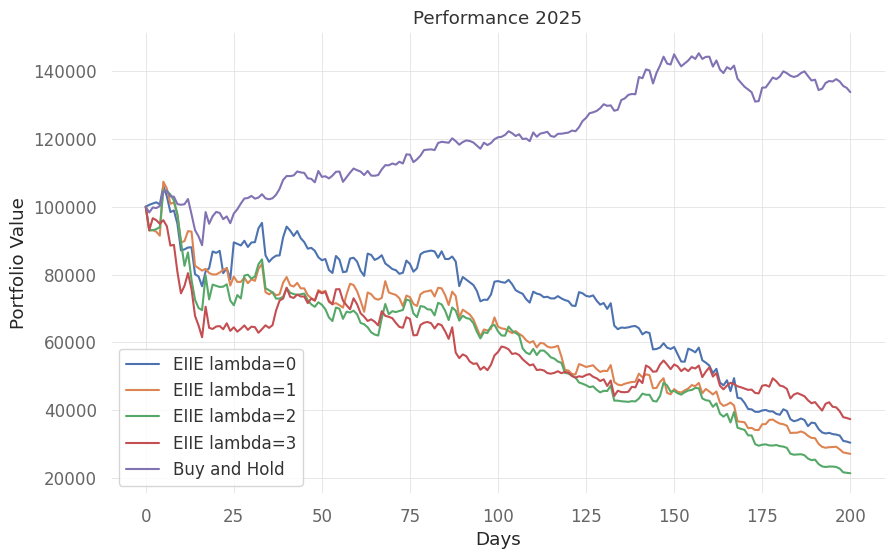

In [ ]:
eiie_test_env_2025 = EIIERiskConditionedEnv(
    df_test_2025,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=['close', 'high', 'low'],
    lam_max = 0, # Doesn't matter
    random_start=False
)

all_results = []

for model_info in eiie_model_list:
    EIIE_test_results = {"2025": {}, "label": None}
    EIIE_test_results["label"] = "EIIE lambda=" + str(model_info[0])
    all_results.append(EIIE_test_results)
    DRLAgent_PO.DRL_validation(
                    model_info[1],
                    eiie_test_env_2025,
                    policy=model_info[1].train_policy
                )
    EIIE_test_results["2025"]["value"] = eiie_test_env_2025._asset_memory["final"]
    EIIE_test_results["2025"]["rewards"] = eiie_test_env_2025._portfolio_reward_memory
    #run_test(model_info[1].train_policy, eiie_environment_2025, model_info[0])

all_results.append(UBAH_results)
plot_returns(all_results, "2025")

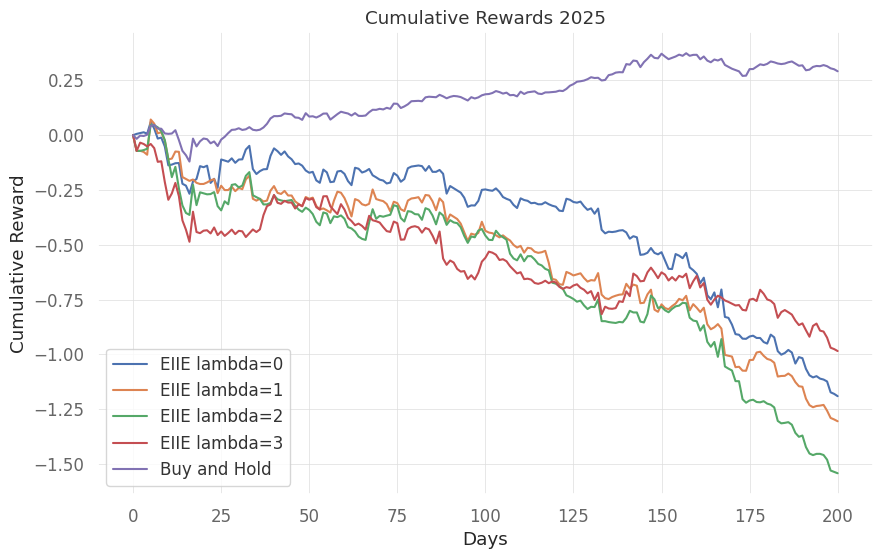

In [ ]:
plot_rewards(all_results, "2025")

In [ ]:
# Print weight distribution
averages = np.mean(eiie_test_env_2025._final_weights, axis=0)
print(averages)

[0.00497512 0.069672   0.18933836 0.05840591 0.04571622 0.09174074
 0.05503185 0.256983   0.00084403 0.02359014 0.20370252]


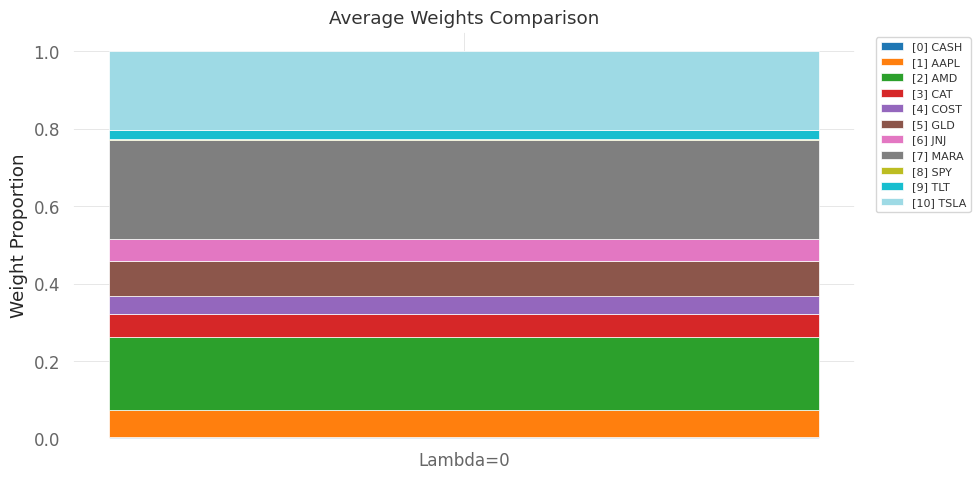

In [ ]:
def plot_eiie_weights(env_dict, title="Average Weights Comparison"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Check if env_dict is just a single env for backward compatibility
    if not isinstance(env_dict, dict):
        env_dict = {"Average Weights": env_dict}

    labels = list(env_dict.keys())
    # Get a list of tics from the first environment
    first_env = list(env_dict.values())[0]
    tics = ["CASH"] + list(first_env._tic_list)

    matrix = []
    for label, env in env_dict.items():
        weights = env._final_weights
        avg_weights = np.mean(weights, axis=0)
        matrix.append(avg_weights)

    matrix = np.stack(matrix)

    bottom = np.zeros(len(labels))
    # Use a colormap for the assets
    strategy_colors = plt.cm.tab20(np.linspace(0, 1, len(tics)))

    for i, tic in enumerate(tics):
        ax.bar(labels, matrix[:, i], bottom=bottom, label=f"[{i}] {tic}",
               color=strategy_colors[i], edgecolor="white", linewidth=0.5)
        bottom += matrix[:, i]

    ax.set_ylabel("Weight Proportion")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

    plt.tight_layout()
    %matplotlib inline
    plt.show()

# Example usage for a single environment
plot_eiie_weights({"Lambda=0": eiie_test_env_2025})

### EIIE (Dynamic Lambda)

In [ ]:
from finrl.agents.portfolio_optimization.models import DRLAgent as DRLAgent_PO

eiie_environment = EIIERiskConditionedEnv(
    df_train,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=['close', 'high', 'low'],
    lam_max = 4,
    random_start=True
)

model_kwargs = {"lr": 0.01, "policy": EIIE, "batch_size":48}
policy_kwargs = {"k_size": 3, "time_window": 50, "initial_features": 4}
eiie_model = DRLAgent_PO(eiie_environment).get_model("pg", device, model_kwargs, policy_kwargs)
print(f"batch_size: {eiie_model.batch_size}")
DRLAgent_PO.train_model(eiie_model, episodes=400) #episodes=100

EIIE_results = {"training": eiie_environment._asset_memory["final"]}

Normalizing ['close', 'high', 'low'] by previous time...
batch_size: 48


  1%|▏         | 5/400 [00:12<16:40,  2.53s/it]

Lambda: 0.3767093915505981
Episode: 5
Final portfolio value: 126034.61
Final weights: [1.73981967e-08 9.40915272e-02 1.11105226e-01 1.03578888e-01
 1.01452902e-01 1.02701925e-01 1.00361913e-01 8.37103873e-02
 1.01722397e-01 1.04408830e-01 9.68660191e-02]


  2%|▎         | 10/400 [00:25<16:25,  2.53s/it]

Lambda: 1.8015437515822685
Episode: 10
Final portfolio value: 122847.13
Final weights: [7.76087797e-16 9.92470533e-02 1.03048392e-01 9.95508507e-02
 9.78159755e-02 1.01691447e-01 1.01516150e-01 8.49483758e-02
 1.00235134e-01 1.00514941e-01 1.11431591e-01]


...

Lambda: 3.4021347167631304
Episode: 390
Final portfolio value: 40609.984
Final weights: [0.0000000e+00 2.6356190e-28 7.6469838e-40 2.0576951e-25 1.5352073e-23
 4.8842670e-18 1.1939841e-20 1.0000000e+00 9.6352254e-26 3.6903274e-20
 3.4816662e-41]


 99%|█████████▉| 395/400 [16:32<00:12,  2.48s/it]

Lambda: 0.04921074355441135
Episode: 395
Final portfolio value: 28028444.0
Final weights: [0.0000000e+00 2.4869130e-05 4.5128655e-17 1.2301942e-06 4.8919837e-08
 5.4928501e-07 1.1542787e-09 7.2147570e-18 2.3107093e-08 1.0835419e-11
 9.9997330e-01]


100%|██████████| 400/400 [16:45<00:00,  2.51s/it]

Lambda: 1.7692565082715728
Episode: 400
Final portfolio value: 732359.4
Final weights: [0.0000000e+00 2.3935453e-39 9.4544500e-35 1.6698304e-28 3.0990968e-32
 6.9833621e-33 3.5018572e-31 1.0000000e+00 1.1265267e-31 2.2161145e-30
 2.7723938e-34]


In [ ]:
path = "/content/drive/MyDrive/RL Project/"
model_name = "eiie_dyn_final_model.pt"
torch.save(eiie_model.train_policy.state_dict(), path + model_name)
print(f"Saved {model_name}")

Saved eiie_dyn_final_model.pt


Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 38419.984375
Final accumulative portfolio value: 0.384199857711792
Maximum DrawDown: -0.6251533203124999
Sharpe ratio: -1.9742896953809983
Initial portfolio value:100000
Final portfolio value: 38418.15234375
Final accumulative portfolio value: 0.38418152928352356
Maximum DrawDown: -0.6251668359375
Sharpe ratio: -1.974390112389891
Initial portfolio value:100000
Final portfolio value: 38419.9140625
Final accumulative portfolio value: 0.3841991424560547
Maximum DrawDown: -0.6251499218750001
Sharpe ratio: -1.9743065836470217
Initial portfolio value:100000
Final portfolio value: 38418.328125
Final accumulative portfolio value: 0.38418328762054443
Maximum DrawDown: -0.625165625
Sharpe ratio: -1.9743868251016574


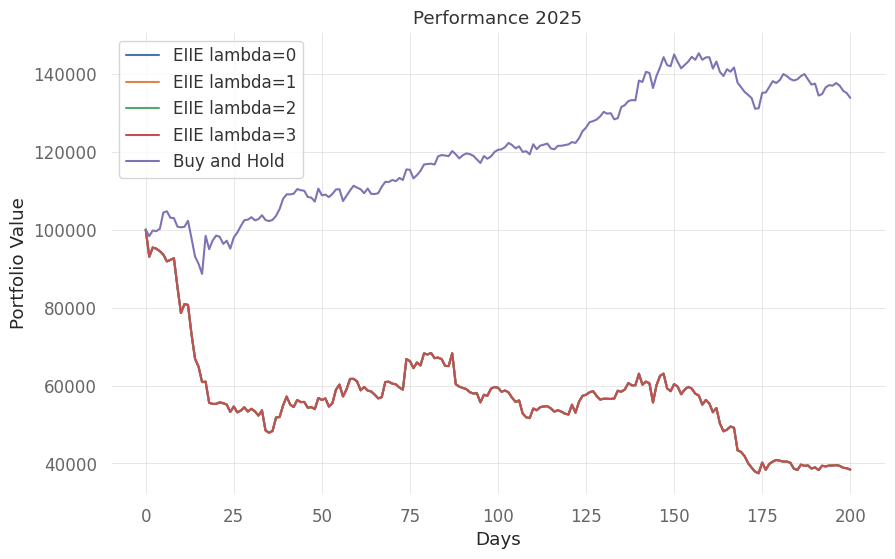

In [ ]:
eiie_test_env_2025 = EIIERiskConditionedEnv(
    df_test_2025,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=50,
    features=['close', 'high', 'low'],
    lam_max = 0, # Doesn't matter
    random_start=False
)

all_results = []

for lam in [0, 1, 2, 3]:
    EIIE_test_results = {"2025": {}, "label": None}
    EIIE_test_results["label"] = "EIIE lambda=" + str(lam)
    eiie_test_env_2025.set_lambda(lam)
    DRLAgent_PO.DRL_validation(
                    eiie_model,
                    eiie_test_env_2025,
                    policy=eiie_model.train_policy
                )
    EIIE_test_results["2025"]["value"] = eiie_test_env_2025._asset_memory["final"]
    EIIE_test_results["2025"]["rewards"] = eiie_test_env_2025._portfolio_reward_memory
    all_results.append(EIIE_test_results)
    #run_test(model_info[1].train_policy, eiie_environment_2025, model_info[0])

all_results.append(UBAH_results)
plot_returns(all_results, "2025")

In [ ]:
# Print weight distribution
averages = np.mean(eiie_test_env_2025._final_weights, axis=0)
print(averages)

[4.9751243e-03 5.1294465e-02 2.1600288e-01 9.7058147e-02 3.8063634e-02
 7.4353948e-02 5.6574855e-02 2.4700138e-01 2.3019333e-05 2.6292933e-02
 1.8835954e-01]


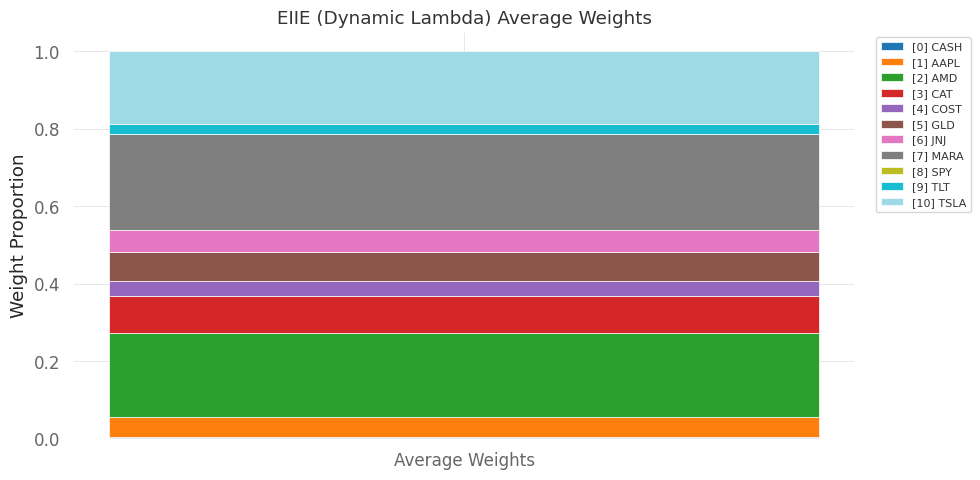

In [ ]:
plot_eiie_weights(eiie_test_env_2025, title="EIIE (Dynamic Lambda) Average Weights")

Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 38419.984375
Final accumulative portfolio value: 0.384199857711792
Maximum DrawDown: -0.6251533203124999
Sharpe ratio: -1.9742896953809983
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 38418.15234375
Final accumulative portfolio value: 0.38418152928352356
Maximum DrawDown: -0.6251668359375
Sharpe ratio: -1.974390112389891
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 38419.9140625
Final accumulative portfolio value: 0.3841991424560547
Maximum DrawDown: -0.6251499218750001
Sharpe ratio: -1.9743065836470217
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 38418.328125
Final accumulative portfolio value: 0.38418328762054443
Maximum DrawDown: -0.625165625
Sharpe ratio: -1.9743868251016574


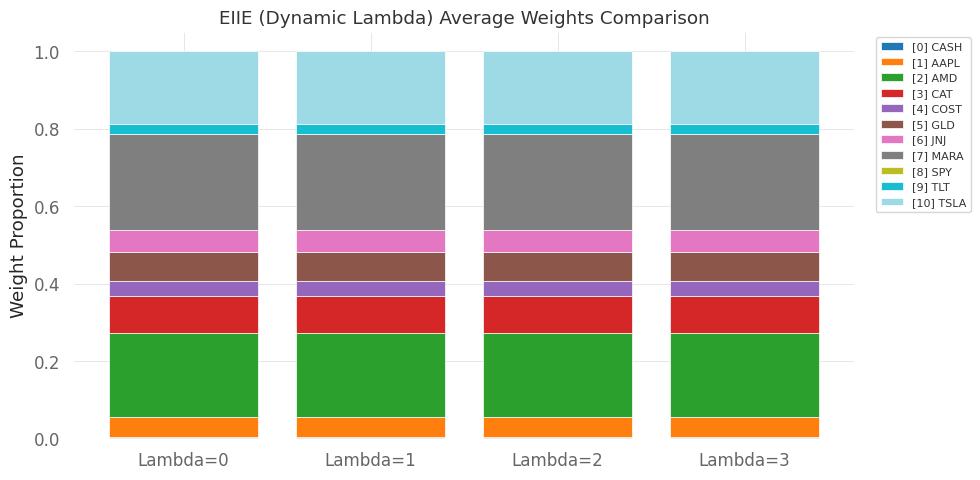

In [ ]:
dynamic_env_dict = {}

# Evaluate the dynamic EIIE model at different risk aversion levels
for lam in [0, 1, 2, 3]:
    test_env = EIIERiskConditionedEnv(
        df_test_2025,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=50,
        features=['close', 'high', 'low'],
        lam_max = 0,
        random_start=False
    )
    test_env.set_lambda(lam)

    # Run validation to populate the environment's memory
    DRLAgent_PO.DRL_validation(
        eiie_model,
        test_env,
        policy=eiie_model.train_policy
    )

    dynamic_env_dict[f"Lambda={lam}"] = test_env

# Plot the comparison
plot_eiie_weights(dynamic_env_dict, title="EIIE (Dynamic Lambda) Average Weights Comparison")

## PPO

In [ ]:
import torch as th
from finrl.agents.stablebaselines3.models import DRLAgent

policy_kwargs = dict(
    net_arch=dict(pi=[256, 256], vf=[256, 256]),
    activation_fn=th.nn.Tanh,
)

model_kwargs = {
    "n_steps": 512,
    "batch_size": 256,
    "n_epochs": 5,
    "ent_coef": 0.01,
    "learning_rate": 3e-4,
}

agent = DRLAgent(env=train_vec_env)
model_ppo = agent.get_model("ppo", model_kwargs=model_kwargs, policy_kwargs=policy_kwargs, policy="MultiInputPolicy")

stop_callback = StopTrainingOnMaxEpisodes(max_episodes=1000, verbose=0)
# stop_callback = StopTrainingOnMaxEpisodes(max_episodes=1, verbose=0)

trained_ppo = model_ppo.learn(total_timesteps=200000, callback=stop_callback)
# trained_ppo = model_ppo.learn(total_timesteps=200, callback=stop_callback)

Streaming output truncated to the last 5000 lines.
|    loss                 | -0.127      |
|    n_updates            | 885         |
|    policy_gradient_loss | -0.00771    |
|    std                  | 1.04        |
|    value_loss           | 0.119       |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 500         |
|    ep_rew_mean          | 0.0525      |
| time/                   |             |
|    fps                  | 175         |
|    iterations           | 179         |
|    time_elapsed         | 522         |
|    total_timesteps      | 91648       |
| train/                  |             |
|    approx_kl            | 0.019904811 |
|    clip_fraction        | 0.123       |
|    clip_range           | 0.2         |
|    entropy_loss         | -16.1       |
|    explained_variance   | 4.23e-06    |
|    learning_rate        | 0.0003      |
|    loss                

Initial portfolio value:100000
Final portfolio value: 132264.8125
Final accumulative portfolio value: 1.3226481676101685
Maximum DrawDown: -0.13462369476217861
Sharpe ratio: 1.6738835415033748


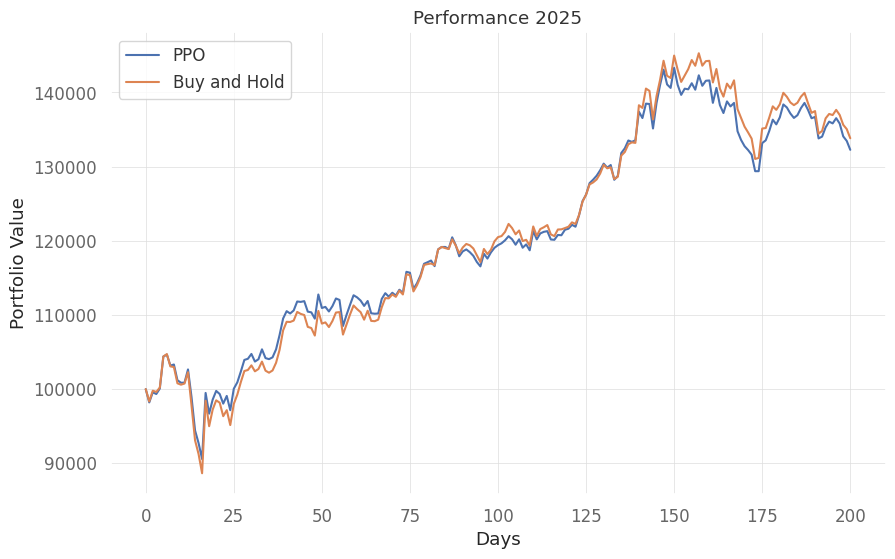

In [ ]:
PPO_results = {"2025": {}, "label": "PPO"}

obs, info = test_env_2025.reset()
done = False
while not done:
    action, _ = trained_ppo.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env_2025.step(action)
PPO_results["2025"]["value"] = test_env_2025._asset_memory["final"]
PPO_results["2025"]["rewards"] = test_env_2025._portfolio_reward_memory

# Remove any existing PPO or UBAH to prevent duplicates, then append
all_results = [res for res in all_results if res.get("label") not in ["PPO", "Buy and Hold"]]
all_results.append(PPO_results)
all_results.append(UBAH_results)

plot_returns(all_results, "2025")

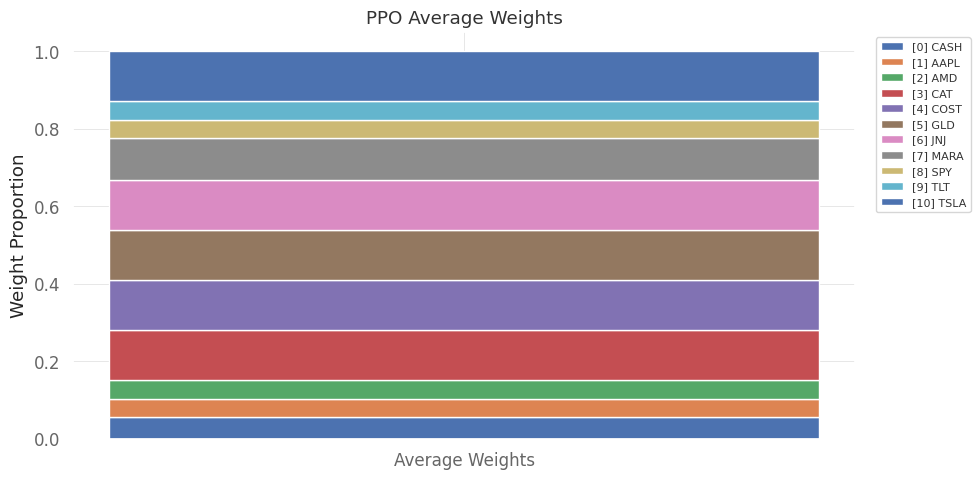

In [ ]:
plot_eiie_weights(test_env_2025, title="PPO Average Weights")

In [ ]:
path = "/content/drive/MyDrive/RL Project/"
model_name_ppo = "ppo_final_model"
trained_ppo.save(path + model_name_ppo)
print(f"Saved {model_name_ppo}")

Saved ppo_final_model


## SAC

In [ ]:
from stable_baselines3 import SAC

model_kwargs = {
    "learning_rate": 3e-4,
    "batch_size": 256,
    "buffer_size": 100_000,
    "learning_starts": 1000,
    "tau": 0.005,
    "gamma": 0.99,
    "ent_coef": "auto",
    "target_entropy": "auto",
}

policy_kwargs = dict(
    net_arch=[256, 256],
    activation_fn=th.nn.Tanh,
)

model_sac = SAC(
    "MultiInputPolicy",
    train_vec_env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    **model_kwargs
)

stop_callback = StopTrainingOnMaxEpisodes(max_episodes=1000, verbose=0)
# stop_callback = StopTrainingOnMaxEpisodes(max_episodes=1, verbose=0)

trained_sac = model_sac.learn(total_timesteps=200000, callback=stop_callback)
# trained_sac = model_sac.learn(total_timesteps=200, callback=stop_callback)

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | 0.599    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 70       |
|    time_elapsed    | 28       |
|    total_timesteps | 2000     |
| train/             |          |
|    actor_loss      | -45      |
|    critic_loss     | 12.3     |
|    ent_coef        | 0.741    |
|    ent_coef_loss   | -5.55    |
|    learning_rate   | 0.0003   |
|    n_updates       | 999      |
---------------------------------
Lambda: 0.0
Episode: 405
Final portfolio value: 87484.984
Final weights: [0.06490908 0.07682389 0.10483751 0.06823764 0.08768888 0.13902695
 0.05503415 0.06974048 0.13740472 0.07271829 0.12357843]
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -0.461   |
| time/              |          |
|    episodes        | 8        |
|   

Initial portfolio value:100000
Final portfolio value: 131737.203125
Final accumulative portfolio value: 1.3173720836639404
Maximum DrawDown: -0.13238329407627292
Sharpe ratio: 1.7586140728284136


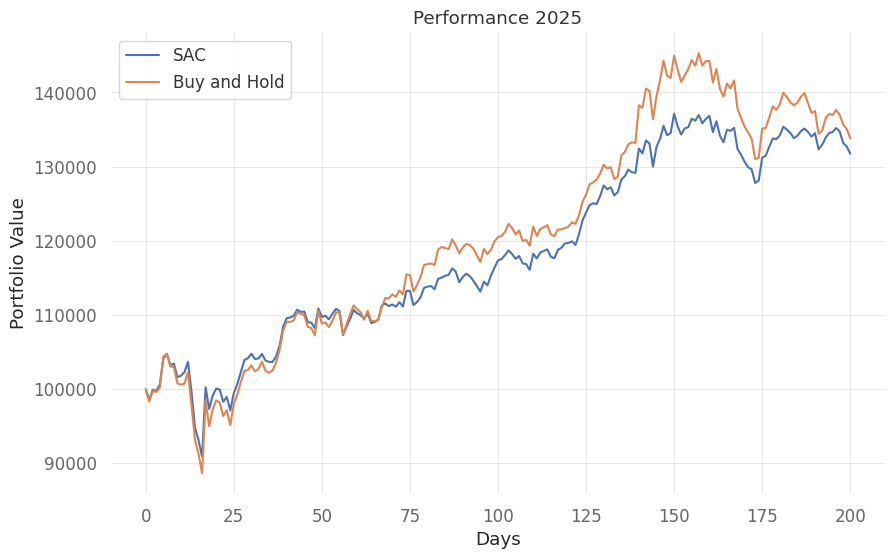

In [ ]:
SAC_results = {"2025": {}, "label": "SAC"}

obs, info = test_env_2025.reset()
done = False
while not done:
    action, _ = trained_sac.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env_2025.step(action)
SAC_results["2025"]["value"] = test_env_2025._asset_memory["final"]
SAC_results["2025"]["rewards"] = test_env_2025._portfolio_reward_memory

# Remove any existing SAC or UBAH to prevent duplicates, then append
all_results = [res for res in all_results if res.get("label") not in ["SAC", "Buy and Hold"]]
all_results.append(SAC_results)
all_results.append(UBAH_results)

plot_returns(all_results, "2025")

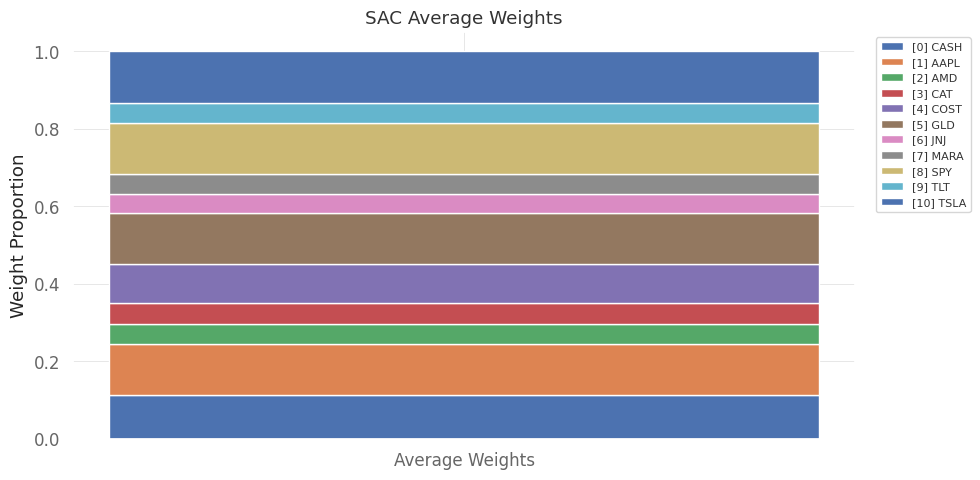

In [ ]:
plot_eiie_weights(test_env_2025, title="SAC Average Weights")

In [ ]:
path = "/content/drive/MyDrive/RL Project/"
model_name_sac = "sac_final_model"
trained_sac.save(path + model_name_sac)
print(f"Saved {model_name_sac}")

Saved sac_final_model


## DQN

In [ ]:
from stable_baselines3 import DQN
from collections import Counter


env_tickers = sorted(df_portfolio["tic"].unique().tolist())
num_cols = 1 + len(env_tickers) # all-cash position + stocks
print(f"Tickers:", env_tickers)

In [ ]:
STRATEGIES = {
    "Full Cash":        {"CASH": 1.0},
    "Very Aggressive":  {"TSLA": 0.30, "MARA": 0.30, "AMD": 0.20, "AAPL": 0.20},
    "Stable Large-Cap": {"SPY": 0.30, "AAPL": 0.20, "JNJ": 0.20, "COST": 0.20, "CAT": 0.10},
    "Bonds + Gold":     {"TLT": 0.45, "GLD": 0.35, "JNJ": 0.10, "COST": 0.10},
}

# Convert our actions into a np array
rows = []
for _, weights in STRATEGIES.items():
    row = np.zeros(num_cols, dtype=np.float32)
    row[0] = weights.get("CASH", 0.0)
    for i, tic in enumerate(env_tickers):
        row[i + 1] = weights.get(tic, 0.0)
    if row.sum() <= 0:
        row[0] = 1.0
    rows.append(row / row.sum())

DISCRETE_ACTIONS = np.stack(rows, dtype=np.float32)
ACTION_NAMES = list(STRATEGIES.keys())
NUM_ACTIONS = len(DISCRETE_ACTIONS)

In [ ]:
class DiscretePortfolioWrapper(gym.Wrapper):
    """
    Wraps PortfolioOptimizationEnv (continuous Box action space) so
    that DQN (requires Discrete action space) can be used.

    Also flattens the observation to a 1D Box, since DQN's MlpPolicy
    requires flat observations (handles both Box and Dict obs spaces).
    """

    def __init__(self, env, discrete_actions: np.ndarray):
        super().__init__(env)
        self._discrete_actions = discrete_actions.astype(np.float32)
        self.action_space = spaces.Discrete(len(discrete_actions))

        obs_space = env.observation_space
        if isinstance(obs_space, spaces.Dict):
            state_dim = int(np.prod(obs_space["state"].shape))
            last_action_dim = int(np.prod(obs_space["last_action"].shape))
            flat_dim = state_dim + last_action_dim
            self._obs_is_dict = True
        else:
            flat_dim = int(np.prod(obs_space.shape))
            self._obs_is_dict = False

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(flat_dim,), dtype=np.float32
        )

    def _flatten_obs(self, obs):
        if self._obs_is_dict:
            return np.concatenate([
                obs["state"].flatten(),
                obs["last_action"].flatten()
            ]).astype(np.float32)
        return obs.flatten().astype(np.float32)

    def reset(self, **kwargs):
        kwargs.pop("seed", None)
        kwargs.pop("options", None)

        result = self.env.reset(**kwargs)
        if isinstance(result, tuple):
            obs, info = result
            return self._flatten_obs(obs), info
        return self._flatten_obs(result), {}

    def step(self, action: int):
        continuous_action = self._discrete_actions[int(action)]
        result = self.env.step(continuous_action)
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            return self._flatten_obs(obs), reward, terminated, truncated, info
        else:
            obs, reward, done, info = result
            return self._flatten_obs(obs), float(reward), done, False, info

In [ ]:
def print_line_break():
    print("\n" + "=" * 60)

In [ ]:
def action_pcts(action_log, num_actions):
    counts = Counter(action_log)
    total = len(action_log)
    return np.array([100 * counts.get(i, 0) / total for i in range(len(action_log))])

def plot_cumulative_actions(results, lambdas):
    test_dist = {lam: action_pcts(results[lam]["action_log"], NUM_ACTIONS) for lam in lambdas}

    fig, ax = plt.subplots(figsize=(10, 5))

    labels = [f"lam={lam}\n(2025)" for lam in lambdas]
    matrix = np.stack([test_dist[lam] for lam in lambdas])

    strategy_colors = plt.cm.tab10(np.linspace(0, 1, NUM_ACTIONS))

    bottom = np.zeros(len(labels))
    for i, name in enumerate(ACTION_NAMES):
        ax.bar(labels, matrix[:, i], bottom=bottom,
            label=f"[{i}] {name}", color=strategy_colors[i],
            edgecolor="white", linewidth=0.5)
        bottom += matrix[:, i]

    ax.set_ylabel("% of steps")
    ax.set_title("Cumulative Action Allocation (2025)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_ylim(0, 100)

    plt.tight_layout()
    %matplotlib inline
    plt.show()

### DQN (Fixed Lambda)

In [ ]:
LAMBDAS = [0.0, 0.1, 0.15, 0.2, 0.3] #[0.0, 0.1, 0.3] #3.0
TOTAL_TIMESTEPS = 120_000 #100_000

dqn_models = {}
DQN_results = {}

for lam in LAMBDAS:
    print_line_break()
    print(f"Training DQN at lambda = {lam}")
    print_line_break()

    base_env = RiskConditionedEnv(
        df_train,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=40,
        features=["close", "high", "low"],
        lam_max=max(LAMBDAS),
        random_start=False,
        return_last_action=True,
      )

    base_env.set_lambda(lam=lam)

    wrapped_env = DiscretePortfolioWrapper(base_env, DISCRETE_ACTIONS)
    vec_env = DummyVecEnv([lambda w=wrapped_env: w])

    model = DQN(
        policy="MlpPolicy",
        env=vec_env,
        learning_rate=1e-4,
        buffer_size=50_000,
        learning_starts=1_000,
        batch_size=64,
        tau=1.0,
        gamma=0.99,
        train_freq=4,
        target_update_interval=500,
        exploration_fraction=0.35,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        policy_kwargs=dict(net_arch=[256, 256]),
        seed=42,
        verbose=0, # quieter per-model; flip to 1 if you want per-step logs
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS)
    print(f"Training complete for lambda = {lam}")

    dqn_models[lam] = (model, wrapped_env, base_env)


Training DQN at lambda = 0.0

Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 233.50106811523438
Final accumulative portfolio value: 0.0023350107949227095
Maximum DrawDown: -0.9976695813359995
Sharpe ratio: -1.376745056150219
Initial portfolio value:100000
Final portfolio value: 562.2335205078125
Final accumulative portfolio value: 0.005622335243970156
Maximum DrawDown: -0.9969985634514453
Sharpe ratio: -0.7834788515360974
Initial portfolio value:100000
Final portfolio value: 149.65570068359375
Final accumulative portfolio value: 0.0014965570298954844
Maximum DrawDown: -0.998568791395871
Sharpe ratio: -1.4438109759032292
Initial portfolio value:100000
Final portfolio value: 725.19775390625
Final accumulative portfolio value: 0.007251977454870939
Maximum DrawDown: -0.9934001134877576
Sharpe ratio: -1.0284564756335657
Initial portfolio value:100000
Final portfolio value: 2160.6630859375
Final accumulative portfolio value: 0.

In [ ]:
DQN_results_2025 = {}

for lam in LAMBDAS:
    model = dqn_models[lam][0]

    test_base_env = RiskConditionedEnv(
        df_test_2025,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=40,
        features=["close", "high", "low"],
        lam_max=max(LAMBDAS), # Doesn't actually matter in this case
        random_start=False,
        return_last_action=True,
    )

    test_base_env.set_lambda(lam=lam)

    test_wrapped_env = DiscretePortfolioWrapper(test_base_env, DISCRETE_ACTIONS)

    obs, info = test_wrapped_env.reset()
    done = False
    action_log = []
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_wrapped_env.step(int(action))
        done = terminated or truncated
        action_log.append(int(action))

    DQN_results_2025[lam] = {
        "portfolio_values": test_base_env._asset_memory["final"],
        "action_log": action_log,
    }

Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 116322.25
Final accumulative portfolio value: 1.1632225513458252
Maximum DrawDown: -0.16379390625
Sharpe ratio: 1.1146170966279252
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 100000.0
Final accumulative portfolio value: 1.0
Maximum DrawDown: 0.0
Sharpe ratio: nan
Normalizing ['close', 'high', 'low'] by previous time...

In [ ]:
model_idx = 0
for lam in LAMBDAS:
    model = dqn_models[lam][0]
    model_name = "dqn_lam_" + str(model_idx) + "_fixed"
    path = "/content/drive/MyDrive/RL Project/"
    model.save(path + model_name)
    model_idx += 1

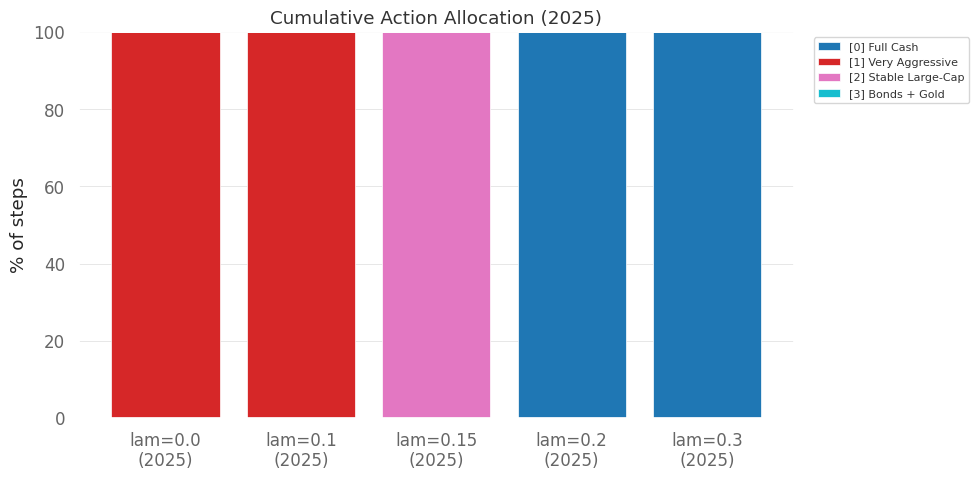

In [ ]:
plot_cumulative_actions(DQN_results_2025, LAMBDAS)

## DQN (dynamic lambda)

In [ ]:
class DiscretePortfolioWrapperWithLambda(gym.Wrapper):
    """
    Wraps PortfolioOptimizationEnv (continuous Box action space) so
    that DQN (requires Discrete action space) can be used.

    Also flattens the observation to a 1D Box, since DQN's MlpPolicy
    requires flat observations (handles both Box and Dict obs spaces).
    """

    def __init__(self, env, discrete_actions: np.ndarray):
        super().__init__(env)
        self._discrete_actions = discrete_actions.astype(np.float32)
        self.action_space = spaces.Discrete(len(discrete_actions))

        obs_space = env.observation_space
        if isinstance(obs_space, spaces.Dict):
            state_dim = int(np.prod(obs_space["state"].shape))
            last_action_dim = int(np.prod(obs_space["last_action"].shape))
            lambda_dim = 1
            flat_dim = state_dim + last_action_dim + lambda_dim
            self._obs_is_dict = True
        else:
            flat_dim = int(np.prod(obs_space.shape))
            self._obs_is_dict = False

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(flat_dim,), dtype=np.float32
        )

    def _flatten_obs(self, obs):
        if self._obs_is_dict:
            return np.concatenate([
                obs["state"].flatten(),
                obs["last_action"].flatten(),
                obs["lambda"].flatten()
            ]).astype(np.float32)
        return obs.flatten().astype(np.float32)

    def reset(self, **kwargs):
        kwargs.pop("seed", None)
        kwargs.pop("options", None)

        result = self.env.reset(**kwargs)
        if isinstance(result, tuple):
            obs, info = result
            return self._flatten_obs(obs), info
        return self._flatten_obs(result), {}

    def step(self, action: int):
        continuous_action = self._discrete_actions[int(action)]
        result = self.env.step(continuous_action)
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            return self._flatten_obs(obs), reward, terminated, truncated, info
        else:
            obs, reward, done, info = result
            return self._flatten_obs(obs), float(reward), done, False, info

In [ ]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import torch.nn as nn

LAMBDA_PROJ_OUTPUT_DIM = 64
STATE_PROJ_OUTPUT_DIM = 128
FEATURES_DIM = LAMBDA_PROJ_OUTPUT_DIM + STATE_PROJ_OUTPUT_DIM

class LambdaFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, obs_space, features_dim = FEATURES_DIM):
        super().__init__(obs_space, features_dim)
        state_dim = obs_space.shape[0] - 1
        lambda_dim = 1
        print(state_dim)
        self.state_proj = nn.Sequential(
            nn.Linear(state_dim, STATE_PROJ_OUTPUT_DIM),
            nn.ReLU()
        )

        self.lambda_proj = nn.Sequential(
            nn.Linear(1, LAMBDA_PROJ_OUTPUT_DIM),
            nn.ReLU()
        )

    def forward(self, obs) -> th.Tensor:
        state_x = obs[:, :-1]
        lam_x = obs[:, -1]
        lam_x = torch.unsqueeze(lam_x, dim=1)
        state_x = self.state_proj(state_x)
        lam_x = self.lambda_proj(lam_x)
        cat_x = torch.cat((state_x, lam_x), dim=1)
        return cat_x

In [ ]:
LAM_MAX = 0.4
TOTAL_TIMESTEPS = 600_000

dqn_models = {}
DQN_results = {}

print_line_break()
print(f"Training DQN at lambda_max = {LAM_MAX}")
print_line_break()

base_env = RiskConditionedEnv(
    df_train,
    initial_amount=100000,
    comission_fee_pct=0.0025,
    time_window=40,
    features=["close", "high", "low"],
    lam_max=LAM_MAX,
    random_start=True,
    return_last_action=True,
  )
base_env.max_ep_len = 750

wrapped_env = DiscretePortfolioWrapperWithLambda(base_env, DISCRETE_ACTIONS)
vec_env = DummyVecEnv([lambda w=wrapped_env: w])

model = DQN(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=1e-4,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=64,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.4,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs=dict(features_extractor_class = LambdaFeatureExtractor,
                       net_arch=[128, 128]),
    seed=42,
    verbose=0, # quieter per-model; flip to 1 if you want per-step logs
)

model.learn(total_timesteps=TOTAL_TIMESTEPS)
print(f"  Training complete for lambda_max = {LAM_MAX}\n")


Training DQN at lambda_max = 0.4

Normalizing ['close', 'high', 'low'] by previous time...
1211
1211
Lambda: 0.03767093915505981
Episode: 5
Final portfolio value: 63203.316
Final weights: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Lambda: 0.18015437515822685
Episode: 10
Final portfolio value: 15512.816
Final weights: [0.         0.         0.         0.         0.09850508 0.35123262
 0.09947423 0.         0.         0.45078805 0.        ]
Lambda: 0.17736567953093246
Episode: 15
Final portfolio value: 101094.875
Final weights: [0.         0.20017014 0.20197988 0.         0.         0.
 0.         0.2901442  0.         0.         0.30770573]
Lambda: 0.2526657596488259
Episode: 20
Final portfolio value: 13009.79
Final weights: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Lambda: 0.31135339882950475
Episode: 25
Final portfolio value: 22277.059
Final weights: [0.         0.         0.         0.         0.10085477 0.35068175
 0.10000334 0.         0.         0.4484602  0.        ]
Lambda: 0.2732195812969819

In [ ]:
eval_lams = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

DQN_results_2025 = {}

for lam in eval_lams:
    test_base_env = RiskConditionedEnv(
        df_test_2025,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=40,
        features=["close", "high", "low"],
        lam_max=max(eval_lams), #doesn't matter here
        random_start=False,
        return_last_action=True,
    )

    test_base_env.set_lambda(lam=lam)

    test_wrapped_env = DiscretePortfolioWrapperWithLambda(test_base_env, DISCRETE_ACTIONS)

    obs, info = test_wrapped_env.reset()
    done = False
    action_log = []
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_wrapped_env.step(int(action))
        done = terminated or truncated
        action_log.append(int(action))

    DQN_results_2025[lam] = {
        "portfolio_values": test_base_env._asset_memory["final"],
        "action_log": action_log,
    }

Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159

In [ ]:
print(DQN_results_2025)

{0.0: {'portfolio_values': [100000, np.float32(99399.22), np.float32(102787.14), np.float32(100383.914), np.float32(102760.73), np.float32(91227.12), np.float32(91559.59), np.float32(93650.26), np.float32(89638.43), np.float32(93777.234), np.float32(92694.086), np.float32(88970.195), np.float32(91912.016), np.float32(91950.37), np.float32(93376.28), np.float32(103269.664), np.float32(104035.7), np.float32(100237.91), np.float32(99591.58), np.float32(94807.7), np.float32(92395.91), np.float32(94297.86), np.float32(97279.266), np.float32(89350.57), np.float32(83886.73), np.float32(82112.4), np.float32(77400.19), np.float32(92678.12), np.float32(87018.25), np.float32(90345.9), np.float32(91909.66), np.float32(91430.53), np.float32(87449.555), np.float32(88237.914), np.float32(85206.86), np.float32(90781.39), np.float32(93679.15), np.float32(95609.88), np.float32(99535.71), np.float32(99047.734), np.float32(100163.07), np.float32(97740.664), np.float32(98989.555), np.float32(100301.734), n

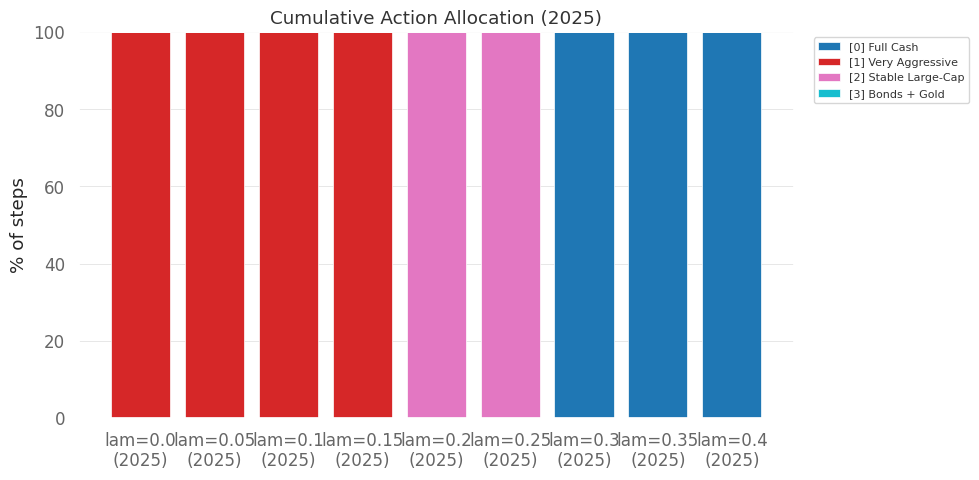

In [ ]:
plot_cumulative_actions(DQN_results_2025, eval_lams)

In [ ]:
model_name = "dqn_dyn_final_model_2"
path = "/content/drive/MyDrive/RL Project/"
model.save(path + model_name)

In [ ]:
# Model Load Example

final_model_name = "dqn_dyn_final_model"
final_model_path = "/content/drive/MyDrive/RL Project/final_models/"

eval_lams = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

loaded_DQN_results_2025 = {}

for lam in eval_lams:
    test_load_env = RiskConditionedEnv(
        df_test_2025,
        initial_amount=100000,
        comission_fee_pct=0.0025,
        time_window=40,
        features=["close", "high", "low"],
        lam_max=max(eval_lams), #doesn't matter here
        random_start=False,
        return_last_action=True,
    )

    test_load_env.set_lambda(lam=lam)

    test_load_wrapped_env = DiscretePortfolioWrapperWithLambda(test_load_env, DISCRETE_ACTIONS)

    loaded_model = DQN.load(final_model_path + final_model_name, env=test_load_wrapped_env)

    obs, info = test_load_wrapped_env.reset()
    done = False
    action_log = []
    while not done:
        action, _ = loaded_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_load_wrapped_env.step(int(action))
        done = terminated or truncated
        action_log.append(int(action))

    loaded_DQN_results_2025[lam] = {
        "portfolio_values": test_load_env._asset_memory["final"],
        "action_log": action_log,
    }

Normalizing ['close', 'high', 'low'] by previous time...
1211
1211
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
1211
1211
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
1211
1211
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.25602283470893783
Sharpe ratio: 0.8351717501159126
Normalizing ['close', 'high', 'low'] by previous time...
1211
1211
Initial portfolio value:100000
Final portfolio value: 128236.96875
Final accumulative portfolio value: 1.2823697328567505
Maximum DrawDown: -0.2560228

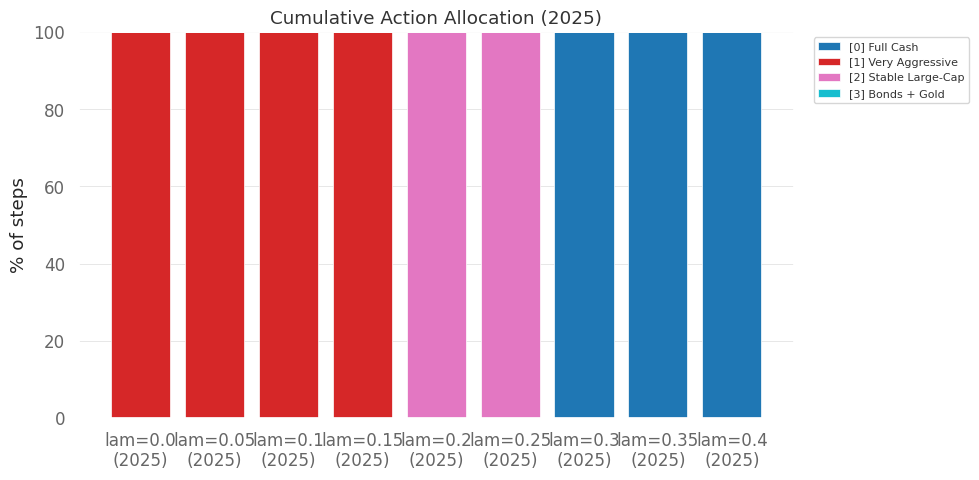

In [ ]:
plot_cumulative_actions(loaded_DQN_results_2025, eval_lams)